requested water_threshold=0.500, effective_water_level=0.500


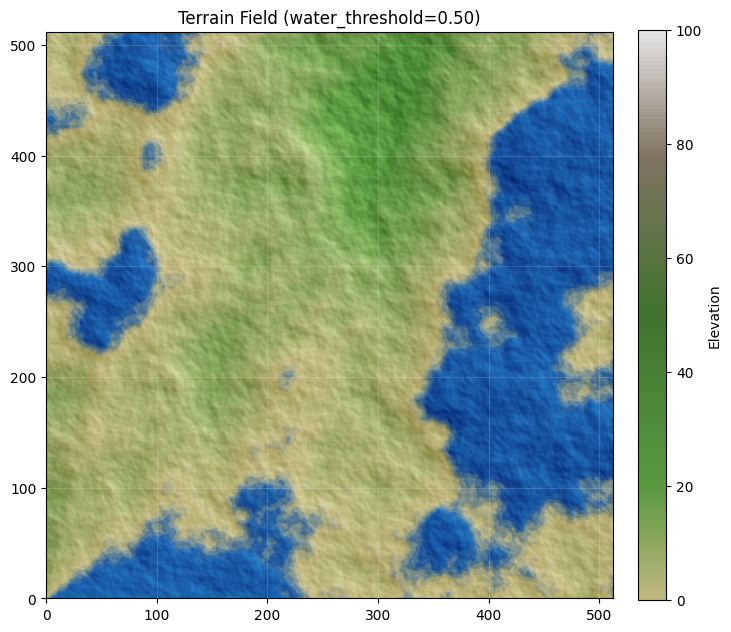

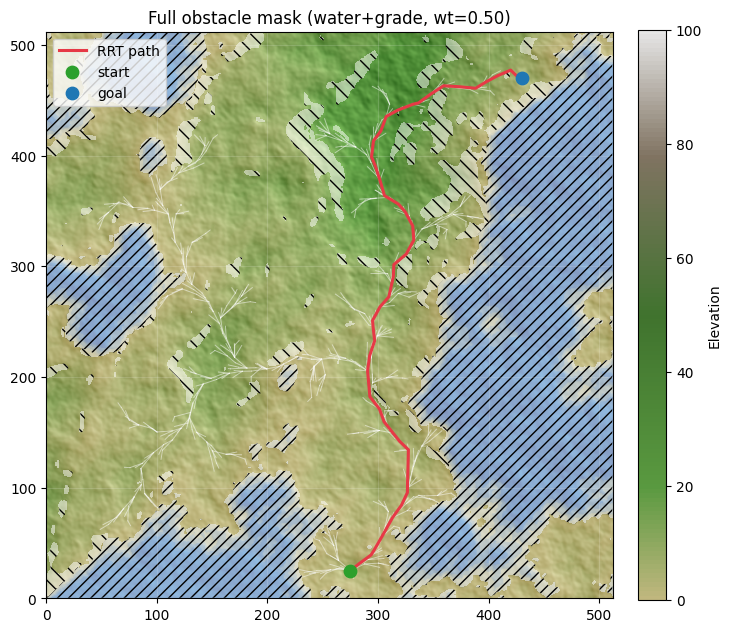

In [ ]:
import torch
from agent import Agent
from planners.RRT import RRTParameters
from utils.FieldClass import TerrainFieldClass
from utils.visualization import plot_agent

swarm = SwarmGraph(type="m_step_path", num_nodes=size, m=3)
swarm.build(adversarial_nodes=adversarial_nodes)
neighbors = swarm.neighbors(rank)

water_threshold = 0.50
terrain_field = TerrainFieldClass(
    seed=42,
    water_threshold=water_threshold,
 )
print(
    f"requested water_threshold={water_threshold:.3f}, "
    f"effective_water_level={terrain_field.effective_water_level:.3f}"
)
terrain_field.plot(title=f"Terrain Field (water_threshold={water_threshold:.2f})")

terrain_agent = Agent(
    rank=0,
    neighbors=[0],
    device=torch.device("cpu"),
    dtype=torch.float64,
    field=terrain_field,
    start=(275.0, 25.0),
    rrt_params=RRTParameters(
        step_size=5.0,
        max_iters=5000,
        seed=8,
        use_rrt_star=True,
    ),
    max_grade=30.0,
 )

end_points = [(220, 460),
              (250, 455),
              (280, 445),
              (310, 455),
              (340, 455),
              (370, 465),
              (400, 470),
              (430, 470)]

terrain_path = terrain_agent.plan_to(end_points[7])

plot_agent(
    terrain_agent,
    show=True,
    title=f"Full obstacle mask (water+grade, wt={water_threshold:.2f})",
    planner_name="RRT",
    include_grade_obstacles=True,
 )

In [50]:
# Print the L2 norms of the distances between neighboring end points
import numpy as np
print("L2 distances between neighboring end points:")
for i in range(len(end_points) - 1):
    dist = np.linalg.norm(np.array(end_points[i]) - np.array(end_points[i + 1]))
    print(f"  {end_points[i]} <-> {end_points[i + 1]}: {dist:.2f}")

L2 distances between neighboring end points:
  (220, 460) <-> (250, 455): 30.41
  (250, 455) <-> (280, 445): 31.62
  (280, 445) <-> (310, 455): 31.62
  (310, 455) <-> (340, 455): 30.00
  (340, 455) <-> (370, 465): 31.62
  (370, 465) <-> (400, 470): 30.41
  (400, 470) <-> (430, 470): 30.00
